This notebook demonstrates how to apply Principal Component Analysis (PCA) to reduce the dimensionality of our image data and visualize the results. The hypothesis is that we can visualize the image similarity on a plot and see how to approach a classifier for "clear sky", "cloudy sky", and so forth.

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from dask.array.image import imread

def load_images(selection):
    images = imread(f"../../images/{selection}/2025-10/*.JPG")[:,:,:,0].compute()
    return images

def get_pca_transform(pca: PCA, images):
    return pca.transform(images.reshape(images.shape[0], -1))

In [7]:
pca = PCA(n_components=2)

nightsky_images = load_images("NightSkyImages")
pca.fit(nightsky_images.reshape(nightsky_images.shape[0], -1))

nightsky_reduction = get_pca_transform(pca, nightsky_images)
del nightsky_images

selected_images = load_images("SelectedSkyImages")
selected_reduction = get_pca_transform(pca, selected_images)
del selected_images

final_images = load_images("FinalSkyImages")
final_reduction = get_pca_transform(pca, final_images)
del final_images

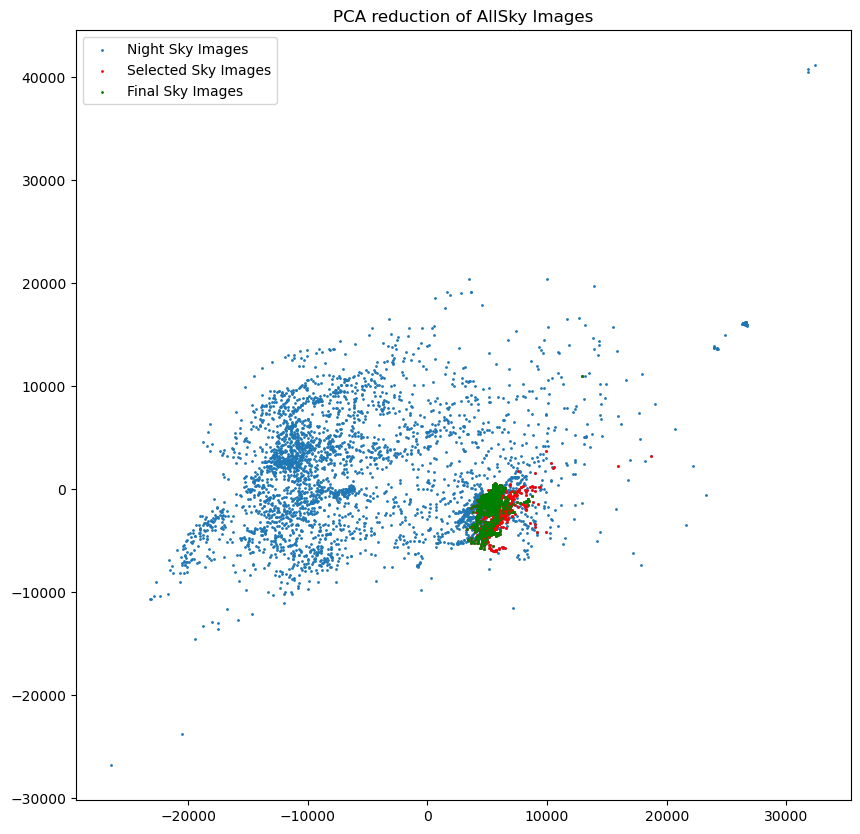

In [8]:
plt.figure(figsize=(10,10))
plt.title(f"PCA reduction of AllSky Images")
plt.scatter(nightsky_reduction[:,0], nightsky_reduction[:,1], s=1, label="Night Sky Images")
plt.scatter(selected_reduction[:,0], selected_reduction[:,1], s=1, c="red", label="Selected Sky Images")
plt.scatter(final_reduction[:,0], final_reduction[:,1], s=1, c="green", label="Final Sky Images")
plt.legend()

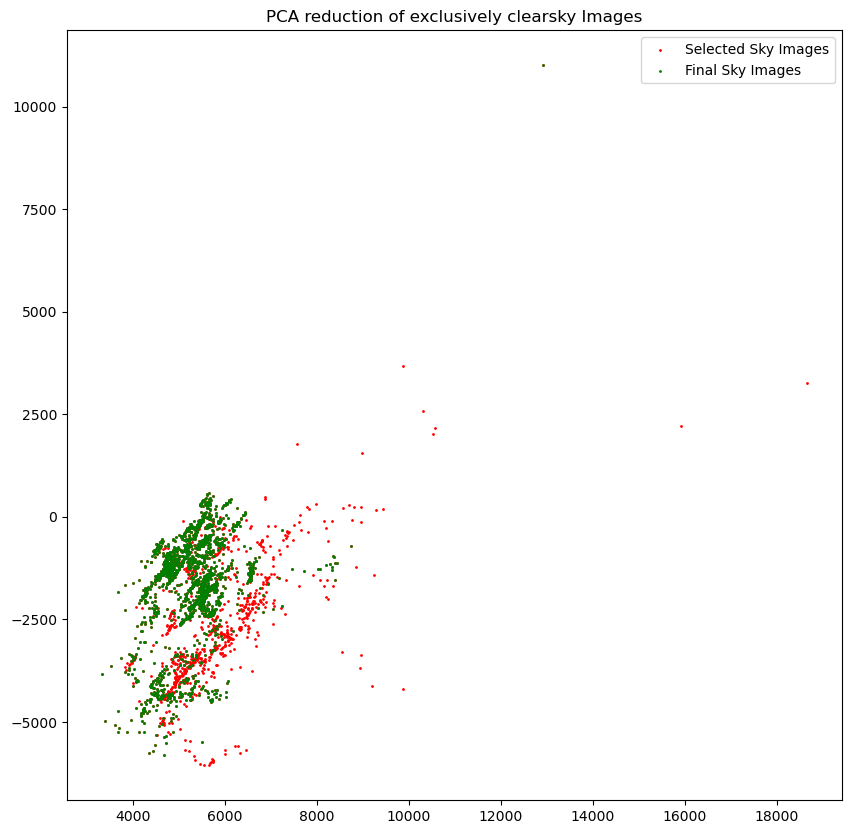

In [9]:
plt.figure(figsize=(10,10))
plt.title(f"PCA reduction of exclusively clearsky Images")
plt.scatter(selected_reduction[:,0], selected_reduction[:,1], s=1, c="red", label="Selected Sky Images")
plt.scatter(final_reduction[:,0], final_reduction[:,1], s=1, c="green", label="Final Sky Images")
plt.legend()

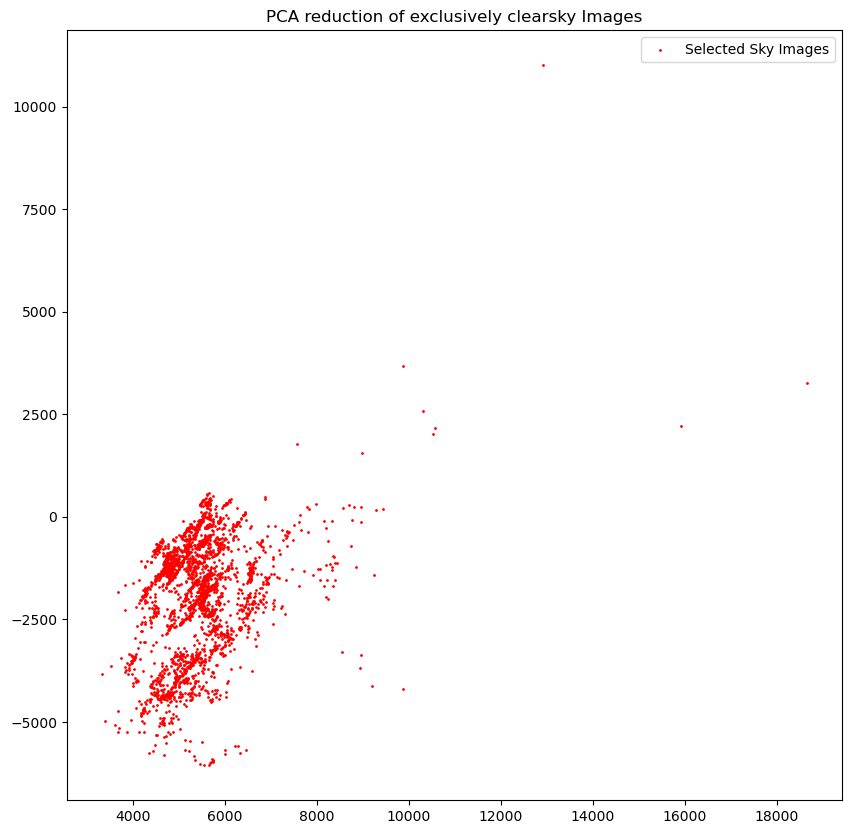

In [10]:
plt.figure(figsize=(10,10))
plt.title(f"PCA reduction of exclusively clearsky Images")
plt.scatter(selected_reduction[:,0], selected_reduction[:,1], s=1, c="red", label="Selected Sky Images")
plt.legend()